In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('✓ Libraries loaded!')

✓ Libraries loaded!


In [3]:
# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print('Dataset Information:')
print('='*60)
print(f'Number of samples: {X.shape[0]}')
print(f'Number of features: {X.shape[1]}')
print(f'Feature names: {feature_names}')
print(f'Target names: {target_names}')
print(f'Class distribution: {np.bincount(y)}')
print('='*60)

# Create DataFrame for visualization
df = pd.DataFrame(X, columns=feature_names)
df['species'] = [target_names[i] for i in y]
print('\nFirst 5 rows:')
print(df.head())

Dataset Information:
Number of samples: 150
Number of features: 4
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Class distribution: [50 50 50]

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [4]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,
                                                    random_state=42, stratify=y)
print(f'Training set size: {x_train.shape[0]}')
print(f'Test set size: {x_test.shape[0]}')
print(f'Training class distribution: {np.bincount(y_train)}')
print(f'Test class distribution: {np.bincount(y_test)}')

Training set size: 120
Test set size: 30
Training class distribution: [40 40 40]
Test class distribution: [10 10 10]


In [11]:
import time
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
print('Training Random Forest...')
start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(x_train, y_train)

training_time = time.time() - start_time

print(f'✅ Training completed in {training_time:.2f} seconds')
print('\nModel parameters:')
print(f' - Number of trees: {rf_model.n_estimators}')
print(f' - Max depth: {rf_model.max_depth}')
print(f' - Number of features: {rf_model.n_features_in_}')
print(f' - Number of classes: {rf_model.n_classes_}')

Training Random Forest...
✅ Training completed in 0.29 seconds

Model parameters:
 - Number of trees: 100
 - Max depth: 10
 - Number of features: 4
 - Number of classes: 3


MODEL PERFORMANCE
Training Accuracy: 1.0000
Test Accuracy: 0.9000
Overfitting gap: 0.1000

Classification Report (Test Set):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



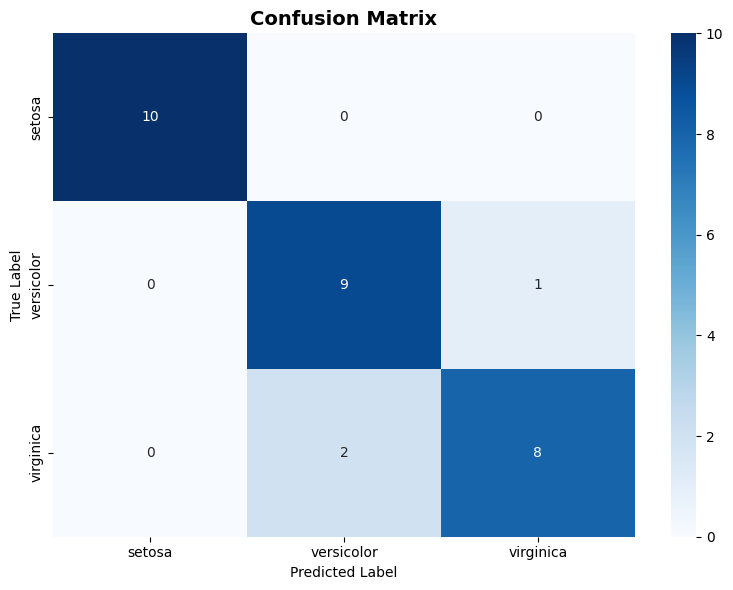


✅ Model training and evaluation complete!


In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions
y_pred_train = rf_model.predict(x_train)
y_pred_test = rf_model.predict(x_test)

# Calculate accuracies
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print('MODEL PERFORMANCE')
print('='*60)
print(f'Training Accuracy: {train_accuracy:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')
print(f'Overfitting gap: {train_accuracy - test_accuracy:.4f}')
print('='*60)

# Detailed classification report
print('\nClassification Report (Test Set):')
print(classification_report(y_test, y_pred_test, target_names=target_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print('\n✅ Model training and evaluation complete!')